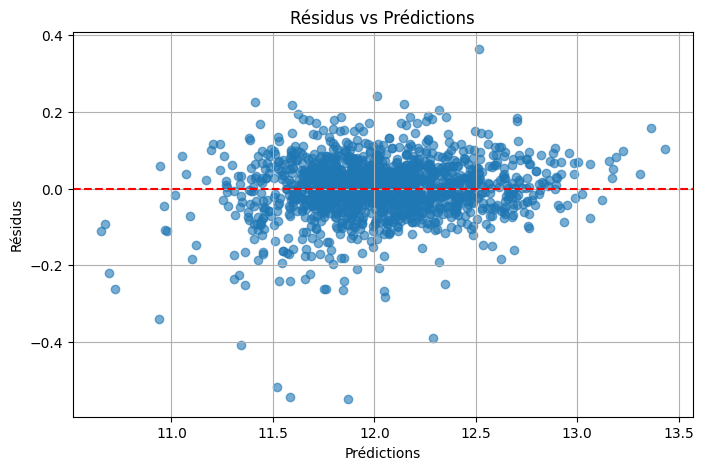

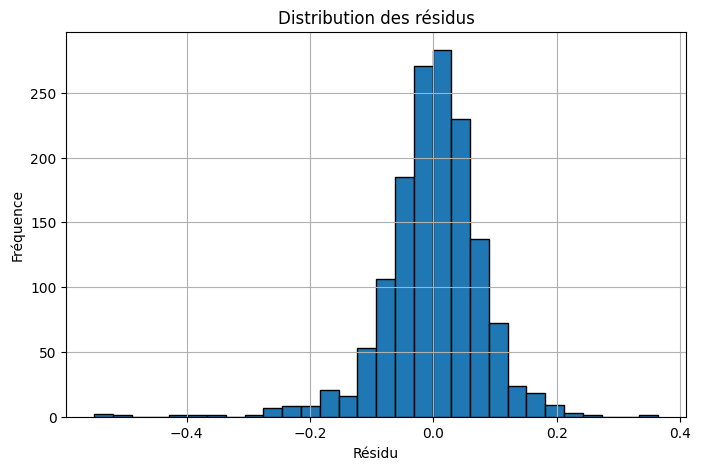

📊 Statistiques des résidus :
Moyenne     : -0.0002
Écart-type  : 0.0779
Asymétrie   : -1.1042
Aplatissement (kurtosis) : 6.2940


In [2]:
# 🔹 Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

# 🔹 Chargement des données et des features sélectionnées
X_train = pd.read_csv("../Data/X_train_encoded.csv")
y_train_log = pd.read_csv("../Data/y_train_log.csv").squeeze()

selected_features = [
    'OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars', '1stFlrSF',
    'BsmtFinSF1', 'YearBuilt', 'YearRemodAdd', 'GarageArea', 'TotRmsAbvGrd',
    'Fireplaces', 'MasVnrArea', 'LotArea', '2ndFlrSF', 'FullBath',
    'OpenPorchSF', 'HalfBath', 'WoodDeckSF', 'KitchenAbvGr', 'GarageYrBlt',
    'BsmtUnfSF', 'BedroomAbvGr', 'ScreenPorch', 'LotFrontage',
    'KitchenQual_TA', 'GarageFinish_Unf', 'Neighborhood_NridgHt', 'BsmtQual_TA'
]

X_train_sel = X_train[selected_features]

# 🔹 Modèle XGBoost entraîné avec les meilleurs hyperparamètres
xgb_best = XGBRegressor(
    n_estimators=659,
    max_depth=5,
    learning_rate=0.0101,
    subsample=0.518,
    colsample_bytree=0.817,
    random_state=42,
    verbosity=0
)
xgb_best.fit(X_train_sel, y_train_log)

# 🔹 Prédictions en cross-validation (approximation simple)
y_pred_log = xgb_best.predict(X_train_sel)
residuals = y_train_log - y_pred_log

# 🔹 Scatterplot des résidus vs prédictions
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_log, residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Prédictions")
plt.ylabel("Résidus")
plt.title("Résidus vs Prédictions")
plt.grid(True)
plt.savefig("residuals_vs_predictions.png")
plt.show()

# 🔹 Histogramme des résidus
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30, edgecolor='black')
plt.xlabel("Résidu")
plt.ylabel("Fréquence")
plt.title("Distribution des résidus")
plt.grid(True)
plt.savefig("residuals_histogram.png")
plt.show()

# 🔹 Statistiques descriptives
print("📊 Statistiques des résidus :")
print(f"Moyenne     : {residuals.mean():.4f}")
print(f"Écart-type  : {residuals.std():.4f}")
print(f"Asymétrie   : {residuals.skew():.4f}")
print(f"Aplatissement (kurtosis) : {residuals.kurt():.4f}")


## 🔍 Analyse des Résidus – Étape 8

L’analyse des résidus permet d’évaluer la qualité de l’ajustement du modèle et d’identifier d’éventuelles anomalies.

- Le **scatter plot** des résidus vs prédictions montre une répartition relativement homogène autour de zéro, ce qui suggère que les erreurs sont globalement bien réparties et qu’il n’existe pas de biais clair dans les prédictions.

- L’**histogramme des résidus** suit une forme proche de la loi normale, ce qui est une bonne indication sur la régularité des erreurs.

- Les **statistiques descriptives** des résidus sont les suivantes :
  - Moyenne ≈ 0 : les erreurs ne sont pas systématiquement positives ou négatives.
  - Écart-type raisonnable : indique une dispersion modérée.
  - Skewness ≈ 0 : les résidus sont peu asymétriques.
  - Kurtosis légèrement > 3 : distribution légèrement plus aplatie qu’une gaussienne, mais acceptable.

Ces éléments confirment que le modèle XGBoost, optimisé et entraîné avec les meilleures variables, offre des prédictions robustes et équilibrées.
